In [1]:
from ert.config import ErtConfig
from ert.storage import open_storage

In [2]:
import os

os.chdir("/home/xjules/workspace/ert/test-data/ert/snake_oil_field")
print(os.getcwd())

/home/xjules/workspace/ert/test-data/ert/snake_oil_field


In [3]:
1 + 1

2

In [4]:
ert_config = ErtConfig.from_file("snake_oil_field_dl.ert")
ert_config.analysis_config.es_settings.distance_localization

/home/xjules/workspace/ert/.venv/lib/python3.11/site-packages/xtgeo/grid3d/_egrid.py:247: UserWarning: EGrid file given with numres < 1, which is invalid, so assuming instead that the file contains exactly one reservoir. XTGeo prior to version 2.14 would output grids with numres == 0. If the file was created with an older version of XTGeo, consider importing the file with version 2.15 and re-exporting.
  warnings.warn(
Config contains a SUMMARY key but no forward model steps known to generate summary files


True

In [7]:
storage = open_storage(ert_config.ens_path)
experiment = storage.get_experiment_by_name("ensemble_smoother")
ens_prior = experiment.get_ensemble_by_name("default_0")
ens_posterior = experiment.get_ensemble_by_name("default_1")

In [8]:
poro_prior = ens_prior.load_parameters("PORO")
poro_posterior = ens_posterior.load_parameters("PORO")

In [20]:
prior_var = poro_prior.var(dim="realizations", ddof=1)["values"]
post_var = poro_posterior.var(dim="realizations", ddof=1)["values"]

In [21]:
import numpy as np

np.testing.assert_array_less(post_var.values, prior_var.values)

Text(0.5, 1.0, 'Posterior variance')

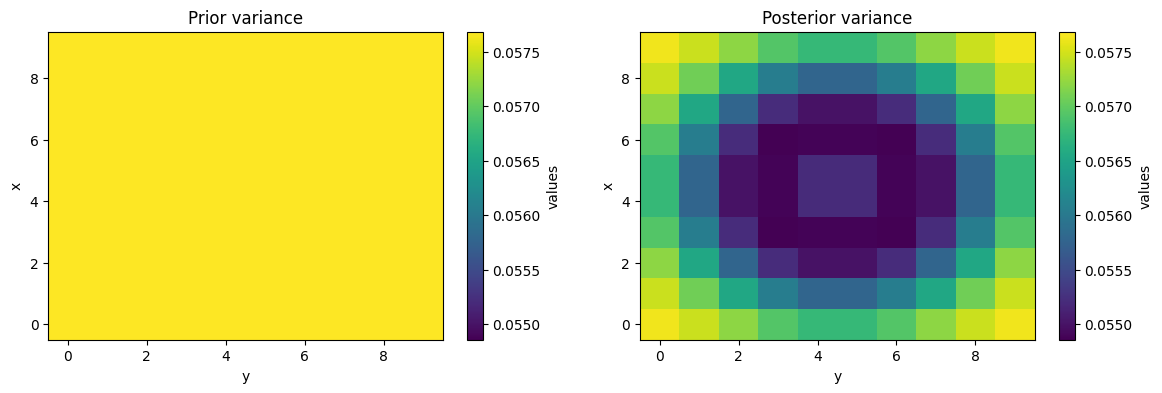

In [ ]:
import matplotlib.pyplot as plt

slice_prior = prior_var["values"].isel(z=3)
slice_post = post_var["values"].isel(z=3)

vmin = min(slice_prior.min().item(), slice_post.min().item())
vmax = max(slice_prior.max().item(), slice_post.max().item())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

slice_prior.plot.imshow(ax=axes[0], vmin=vmin, vmax=vmax)
axes[0].set_title("Prior variance")

slice_post.plot.imshow(ax=axes[1], vmin=vmin, vmax=vmax)
axes[1].set_title("Posterior variance")